<a href="https://colab.research.google.com/github/shravani2919/Datascience_basics/blob/main/Churn_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# This will open a file picker dialog
uploaded = files.upload()


Saving Churn_Modelling.csv to Churn_Modelling.csv


In [4]:
import pandas as pd

# Load the file into a DataFrame
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Clean & Prepare Your Churn Data in Colab


In [5]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)


 Step 2: Encode Categorical Columns

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [8]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)


Check the Cleaned Data

In [9]:
df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


Check for Null or Missing Values

In [10]:
# Check for any missing (null) values
df.isnull().sum()


,0
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(8)
memory usage: 800.9 KB


In [12]:
print(df.columns)


Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')


In [13]:
france_rows = df[(df['Geography_Germany'] == 0) & (df['Geography_Spain'] == 0)]
print(france_rows.shape)
france_rows.head()


(5014, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False


Logistic Regression for Churn Prediction

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


Split your data into features and target

In [15]:
X = df.drop('Exited', axis=1)  # all features
y = df['Exited']               # target


 Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Train Logistic Regression model

In [17]:
model = LogisticRegression(max_iter=1000)  # increase max_iter for convergence
model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)


LogisticRegression()

Train the Model with Scaled Data

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)  # Ensures it has enough iterations to converge
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

 Make Predictions on Test Data

In [21]:
y_pred = model.predict(X_test_scaled)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧮 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Accuracy: 0.811

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


🧮 Confusion Matrix:
 [[1543   64]
 [ 314   79]]


In [23]:
coefficients = pd.DataFrame(model.coef_[0], index=X.columns, columns=['Coefficient'])
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

                   Coefficient
Age                   0.754217
Geography_Germany     0.337190
Balance               0.161139
Geography_Spain       0.038960
EstimatedSalary       0.015744
HasCrCard            -0.010236
Tenure               -0.042637
NumOfProducts        -0.060278
CreditScore          -0.067683
Gender               -0.264718
IsActiveMember       -0.533432


AGE --EXIT

In [26]:
age_churn = df.groupby(['Age', 'Exited']).size().unstack().fillna(0)
age_churn.columns = ['Stayed', 'Churned']
age_churn.head()


,Stayed,Churned
Age,,
18,20.0,2.0
19,26.0,1.0
20,38.0,2.0
21,50.0,3.0
22,72.0,12.0


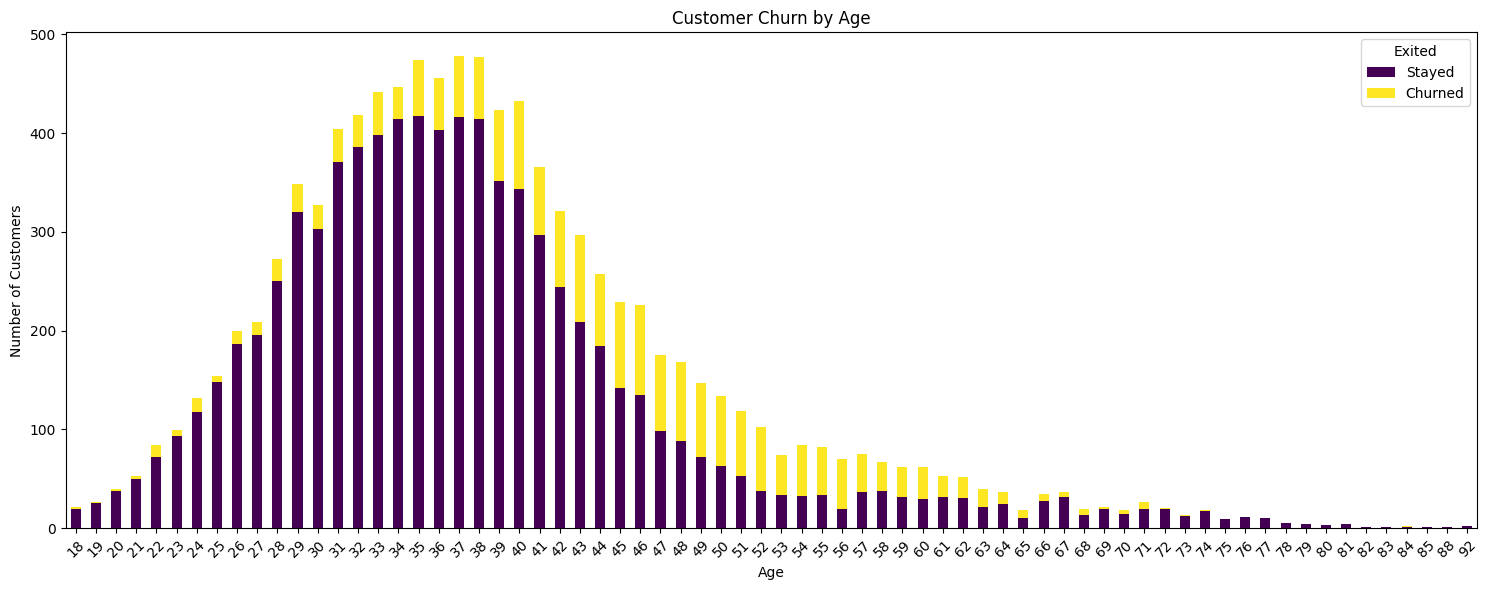

In [27]:
import matplotlib.pyplot as plt

age_churn.plot(kind='bar', stacked=True, figsize=(15, 6), colormap='viridis')
plt.title('Customer Churn by Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Exited')
plt.tight_layout()
plt.show()


In [29]:
age_churn = df.groupby(['Gender', 'Exited']).size().unstack().fillna(0)
age_churn.columns = ['Gender', 'Churned']
age_churn

,Gender,Churned
Gender,,
0,3404,1139
1,4559,898


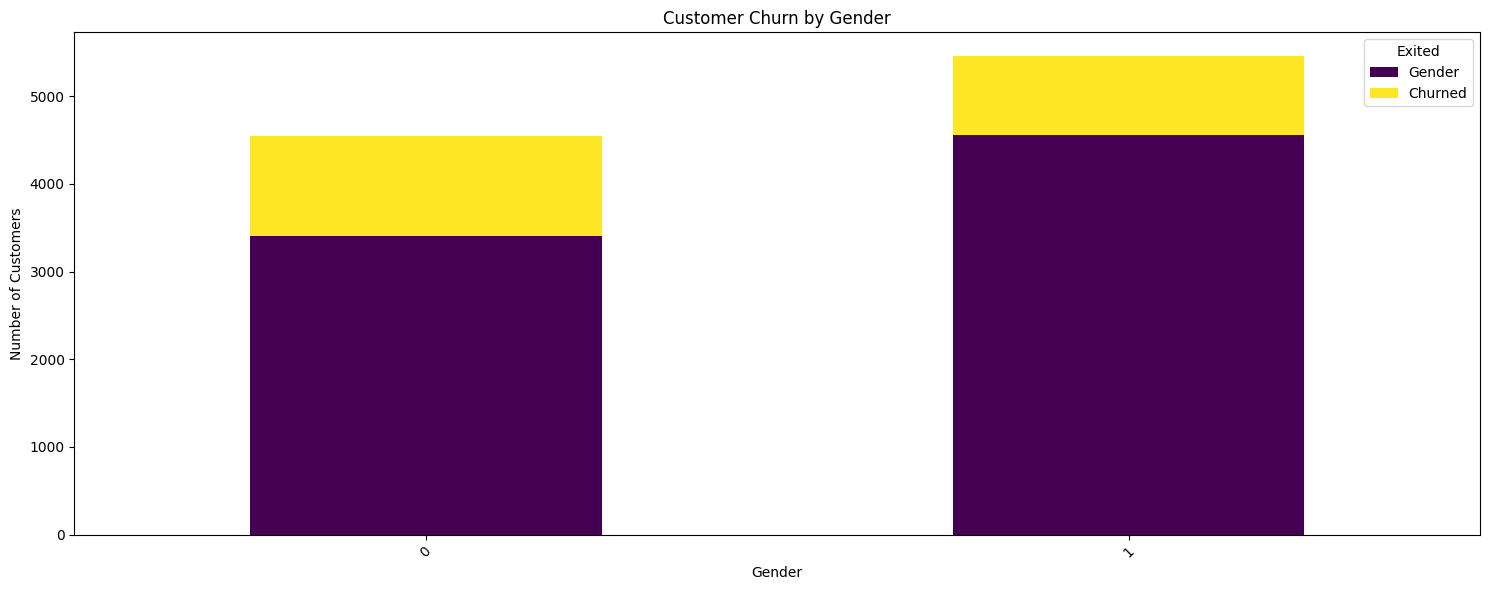

In [30]:
import matplotlib.pyplot as plt

age_churn.plot(kind='bar', stacked=True, figsize=(15, 6), colormap='viridis')
plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Exited')
plt.tight_layout()
plt.show()


In [31]:
import pandas as pd

# Save the transformed DataFrame
df.to_csv("transformed_churn_data.csv", index=False)


In [32]:
from google.colab import files
files.download("transformed_churn_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>